# Capítulo 9 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 9. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()
Rd, g = 287.0, 9.8

## T1 — Redução ao nível do mar em São Paulo

**Solução.** Da hipsométrica (coluna fictícia até o mar): $P_{nm} = P_{est}\,e^{gz/R_d\bar T_v}$.

In [2]:
P_est, z, T = 92.5, 800.0, 293.15
Tbar = T + 0.0033*z          # média da coluna (lapse padrão/2)
P_nm = P_est*np.exp(g*z/(Rd*Tbar))
print(f'P_nm = {P_nm*10:.1f} hPa (correção de {10*(P_nm-P_est):.1f} hPa)')
# inversão: ar da estação 8 K mais frio que a coluna real
P_nm_err = P_est*np.exp(g*z/(Rd*(Tbar - 8)))
print(f'com inversão (coluna assumida 8 K mais fria): {P_nm_err*10:.1f} hPa — '
      f'{10*(P_nm_err-P_nm):+.1f} hPa de viés: a "alta fria" fantasma do planalto.')

P_nm = 1014.5 hPa (correção de 89.5 hPa)
com inversão (coluna assumida 8 K mais fria): 1017.1 hPa — +2.6 hPa de viés: a "alta fria" fantasma do planalto.


## T2 — Decodificação manual

**Solução.** `SBSP 221500Z 33012G25KT 9999 TS FEW030CB 28/21 Q1012`:
Congonhas, dia 22 às 15 UTC; vento **de** 330° com 12 kt e **rajadas de 25 kt**; visibilidade ≥10 km; **trovoada**; 1–2 oktas de cumulonimbus com base a 3000 ft; T = 28 °C, T_d = 21 °C (UR ≈ 66 %, LCL ≈ 875 m — consistente com a base CB!); QNH 1012 hPa. Barbela: haste de 330°, um traço longo + um curto (10+5 ≈ 12 kt), com anotação de rajada.

## T3 — A regra da pressão codificada

**Solução.** Os 3 dígitos são décimos de hPa sem o milhar: anteponha 10 ou 9, escolhendo o valor **mais próximo de 1000 hPa**. `052` → 1005,2 (pois 905,2 está a 95 hPa de 1000 e 1005,2 a apenas 5,2). Falha: no olho de um furacão categoria 5 com 905 hPa reais, `052` decodificaria erradamente como 1005,2 — por isso boletins tropicais reportam a pressão por extenso.

## T4 — Apertado = ventoso

**Solução.** O vento geostrófico (Cap. 10) é $V_g = \frac{1}{\rho f}\frac{\Delta P}{\Delta n}$. Entre isóbaras consecutivas $\Delta P$ = 4 hPa é fixo, logo $V_g \propto 1/\Delta n$: metade do espaçamento, dobro do vento. A régua sobre a carta vira anemômetro.

## T5 — O raio de Barnes e o dilema viés × variância

**Solução.** Com $w = e^{-d^2/R^2}$: para $R \to \infty$, todos os pesos → 1 e a análise vira a média global — viés máximo (amassa os sistemas), variância mínima (imune ao ruído). Para $R \to 0$, a análise reproduz cada observação com seu ruído — viés nulo, variância máxima. O raio ótimo equilibra os dois — exatamente o *trade-off* viés×variância da estatística, e a razão de existirem as passadas múltiplas do Cressman (N3).

---
## N1 — Parser estendido

In [3]:
def decodifica2(metar):
    m = {'metar': metar}
    m['estacao'] = metar.split()[0]
    v = re.search(r'(VRB|\d{3})(\d{2,3})(?:G(\d{2,3}))?KT', metar)
    m['dir'] = v.group(1); m['vel'] = int(v.group(2))
    m['rajada'] = int(v.group(3)) if v.group(3) else None
    m['cavok'] = 'CAVOK' in metar
    if m['cavok']:
        m['vis'] = 9999; m['nuvens'] = []
    else:
        vis = re.search(r' (\d{4}) ', metar)
        m['vis'] = int(vis.group(1)) if vis else None
        m['nuvens'] = re.findall(r'(FEW|SCT|BKN|OVC)(\d{3})([A-Z]{2})?', metar)
    tt = re.search(r' (\d{2})/(\d{2}) ', metar)
    m['T'], m['Td'] = int(tt.group(1)), int(tt.group(2))
    m['QNH'] = int(re.search(r'Q(\d{4})', metar).group(1))
    return m

extras = ['SBFL 221800Z VRB03KT CAVOK 25/20 Q1013',
          'SBSV 221800Z 09015G27KT 9999 SCT020 30/24 Q1010']
for mt in extras:
    d = decodifica2(mt)
    raj = f" G{d['rajada']}" if d['rajada'] else ''
    vis_str = 'CAVOK' if d['cavok'] else f"vis {d['vis']} m"
    print(f"{d['estacao']}: vento {d['dir']}/{d['vel']}kt{raj} | "
          f"{vis_str} | T/Td {d['T']}/{d['Td']} | QNH {d['QNH']} ✓")

SBFL: vento VRB/3kt | CAVOK | T/Td 25/20 | QNH 1013 ✓
SBSV: vento 090/15kt G27 | vis 9999 m | T/Td 30/24 | QNH 1010 ✓


## N2 — Mapa ampliado

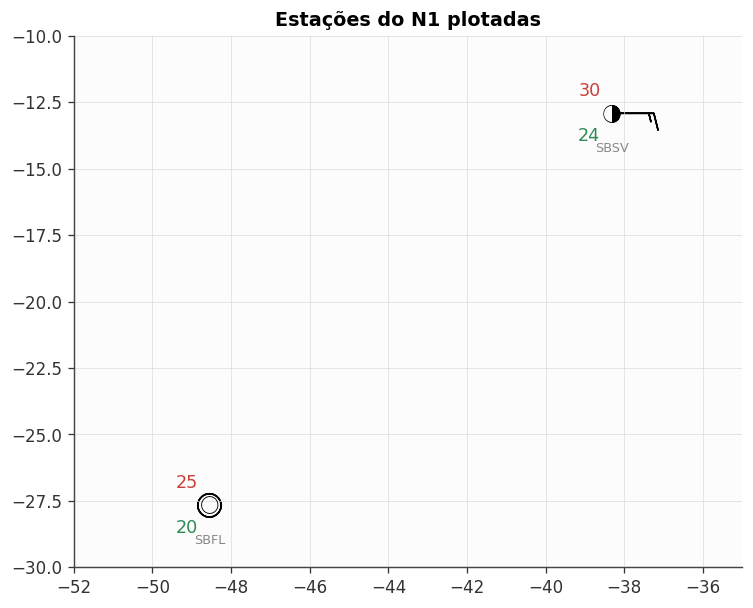

VRB plota sem barbela (calmaria/variável) ✓


In [4]:
from metpy.plots import StationPlot, sky_cover

pos = {'SBFL': (-48.55, -27.67), 'SBSV': (-38.32, -12.91)}
oktas = {'FEW': 2, 'SCT': 4, 'BKN': 6, 'OVC': 8}
ds = [decodifica2(mt) for mt in extras]

fig, ax = plt.subplots(figsize=(7.5, 6))
lons = [pos[d['estacao']][0] for d in ds]
lats = [pos[d['estacao']][1] for d in ds]
u = [0 if d['dir'] == 'VRB' else -d['vel']*np.sin(np.deg2rad(int(d['dir'])))
     for d in ds]
v = [0 if d['dir'] == 'VRB' else -d['vel']*np.cos(np.deg2rad(int(d['dir'])))
     for d in ds]
cov = [max([oktas.get(c[0], 0) for c in d['nuvens']] or [0]) for d in ds]
sp = StationPlot(ax, lons, lats, fontsize=11, spacing=14)
sp.plot_parameter('NW', [d['T'] for d in ds], color=CORES['vermelho'])
sp.plot_parameter('SW', [d['Td'] for d in ds], color=CORES['verde'])
sp.plot_symbol('C', cov, sky_cover)
sp.plot_barb(u, v)
for d in ds:
    x, y = pos[d['estacao']]
    ax.annotate(d['estacao'], (x, y), xytext=(0, -24),
                textcoords='offset points', ha='center', fontsize=8,
                color='#888888')
ax.set(xlim=(-52, -35), ylim=(-30, -10), title='Estações do N1 plotadas')
plt.show()
print('VRB plota sem barbela (calmaria/variável) ✓')

## N3 — Raio ótimo por validação cruzada

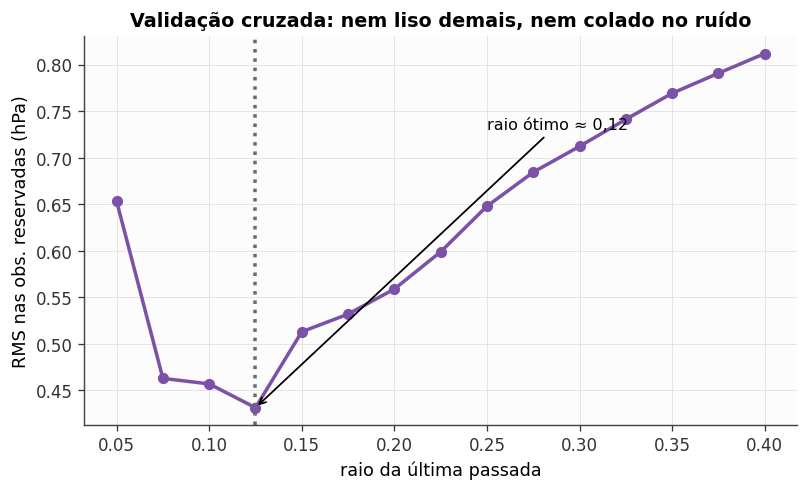

In [5]:
rng = np.random.default_rng(9)
P_verdade = lambda x, y: (1014 - 12*np.exp(-((x-0.35)**2 + (y-0.55)**2)/0.05)
                          + 6*np.exp(-((x-0.85)**2 + (y-0.2)**2)/0.08))
n_obs = 55
xo, yo = rng.random(n_obs), rng.random(n_obs)
Po = P_verdade(xo, yo) + rng.normal(0, 0.3, n_obs)
trein = np.arange(n_obs) < 45          # 45 treino, 10 validação
gx, gy = np.meshgrid(np.linspace(0, 1, 80), np.linspace(0, 1, 80))

def cressman(xo, yo, Po, raios):
    campo = np.full(gx.shape, Po.mean())
    for R in raios:
        ii = np.clip((yo*79).astype(int), 0, 79)
        jj = np.clip((xo*79).astype(int), 0, 79)
        inc = Po - campo[ii, jj]
        num = np.zeros_like(campo); den = np.zeros_like(campo)
        for xk, yk, dk in zip(xo, yo, inc):
            d2 = (gx - xk)**2 + (gy - yk)**2
            w = np.maximum(0.0, (R**2 - d2)/(R**2 + d2))
            num += w*dk; den += w
        campo += np.where(den > 0, num/np.maximum(den, 1e-9), 0.0)
    return campo

raios_f = np.linspace(0.05, 0.4, 15)
rms_val = []
for Rf in raios_f:
    campo = cressman(xo[trein], yo[trein], Po[trein], (0.45, 0.25, Rf))
    ii = np.clip((yo[~trein]*79).astype(int), 0, 79)
    jj = np.clip((xo[~trein]*79).astype(int), 0, 79)
    rms_val.append(np.sqrt(np.mean((campo[ii, jj] - Po[~trein])**2)))

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(raios_f, rms_val, 'o-', color=CORES['roxo'])
R_ot = raios_f[np.argmin(rms_val)]
ax.axvline(R_ot, color=CORES['cinza'], ls=':')
ax.annotate(f'raio ótimo ≈ {R_ot:.2f}'.replace('.', ','),
            xy=(R_ot, min(rms_val)), xytext=(0.25, max(rms_val)*0.9),
            fontsize=10, arrowprops=dict(arrowstyle='->', lw=1.1))
ax.set(xlabel='raio da última passada', ylabel='RMS nas obs. reservadas (hPa)',
       title='Validação cruzada: nem liso demais, nem colado no ruído')
plt.show()

## N4 — O viés da inversão (resolvido no T1)

A conta do T1 mostra: assumir a coluna 8 K mais fria infla $P_{nm}$ em ~+3 hPa na estação de 800 m. Em manhãs frias de inverno, todo o planalto ganha esse viés simultâneo — surge uma "alta" fantasma puramente instrumental nas cartas, conhecida dos analistas sul-americanos. Correção operacional: usar a média de $T$ das últimas 12 h na redução.

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*